# 01 — The precession protocol and the SPIDER state

**Where we are in the story.** Bosonic quantum error correction (QEC) encodes a qubit in the
infinite Hilbert space of a single oscillator. The best studied family, *rotation-symmetric
bosonic codes* (cat, binomial, …), is defined by a discrete rotation symmetry in phase space.
In a completely different context — tests of non-classicality — Zaw, Aw, Lasmar and Scarani
[PRA **106**, 032222 (2022)] found a state that *maximally* violates a classical bound for a
uniformly precessing oscillator. That state happens to be rotation symmetric. This notebook
re-derives it from scratch, because the original notebooks were lost; only their figures survived
(see `figures/legacy/`).

## The protocol

Take a harmonic oscillator $H = \tfrac12(p^2 + x^2)$ (units $\hbar=\omega=1$, period $T=2\pi$).
Prepare any state, pick one of $K$ times $t_k = kT/K$ at random, and record the **sign of $x$**.
The score is

$$P_K = \frac1K \sum_{k=0}^{K-1} \Pr[x(t_k) > 0].$$

For *any* classical precessing object (any probability distribution on phase space) one has, for odd $K$,

$$P_K \le \mathbf P_K^{c} = \tfrac12\left(1 + \tfrac1K\right),$$

and for even $K$ the score is exactly $1/2$. Quantum mechanically $P_K = \langle\psi|\hat Q_K|\psi\rangle$ with

$$\hat Q_K = \frac1K\sum_k \hat U_k^\dagger\, \mathrm{pos}(\hat x)\, \hat U_k ,\qquad \hat U_k = e^{-i\hat n t_k},\qquad \mathrm{pos}(x) = \tfrac12(1+\mathrm{sgn}\,x),$$

and the largest eigenvalue of $\hat Q_K$ exceeds the classical bound. The corresponding eigenvector is the **spider state** $|S_K\rangle$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # make `spiderqec` importable from notebooks/
from spiderqec import precession as pr
from spiderqec import plotting as pl
from spiderqec.rotation_codes import wigner
pl.use_style()
%matplotlib inline

## Step 1 — the projector $\mathrm{pos}(\hat x)$ in the Fock basis

Integrating the Schrödinger equation of the oscillator from $0$ to $\infty$ gives an exact closed form,

$$\langle m|\mathrm{pos}(\hat x)|n\rangle = \tfrac12\delta_{mn} + \frac{\psi_n(0)\psi_m'(0) - \psi_m(0)\psi_n'(0)}{2(m-n)}\ (m\neq n),$$

which vanishes unless $m-n$ is odd. No numerical integration is needed, so truncations of
$10^4$ Fock states are cheap.

In [2]:
P = pr.pos_x_matrix(8)
np.set_printoptions(precision=4, suppress=True)
print(P)

[[ 0.5     0.3989  0.     -0.1629 -0.      0.1093  0.     -0.0843]
 [ 0.3989  0.5     0.2821 -0.     -0.0814 -0.      0.0446 -0.    ]
 [ 0.      0.2821  0.5     0.3455 -0.     -0.1288 -0.      0.0834]
 [-0.1629 -0.      0.3455  0.5     0.2992  0.     -0.091  -0.    ]
 [ 0.     -0.0814 -0.      0.2992  0.5     0.3345  0.     -0.1204]
 [ 0.1093  0.     -0.1288  0.      0.3345  0.5     0.3054 -0.    ]
 [ 0.      0.0446  0.     -0.091   0.      0.3054  0.5     0.3298]
 [-0.0843 -0.      0.0834  0.     -0.1204 -0.      0.3298  0.5   ]]


## Step 2 — why $\hat Q_K$ is block diagonal (the Kronecker comb)

$\hat U_k$ multiplies $|n\rangle$ by $e^{-2\pi i nk/K}$, so

$$(\hat Q_K)_{mn} = \mathrm{pos}_{mn}\,\frac1K\sum_{k}e^{2\pi i (m-n)k/K} = \mathrm{pos}_{mn}\,\delta_{m\equiv n\ (\mathrm{mod}\ K)} .$$

The score operator is just $\mathrm{pos}(\hat x)$ with every matrix element between Fock states of
different residue mod $K$ erased. Its eigenvectors can therefore be chosen inside one residue class —
this is exactly $K$-fold rotation symmetry, and the bridge to bosonic rotation codes.

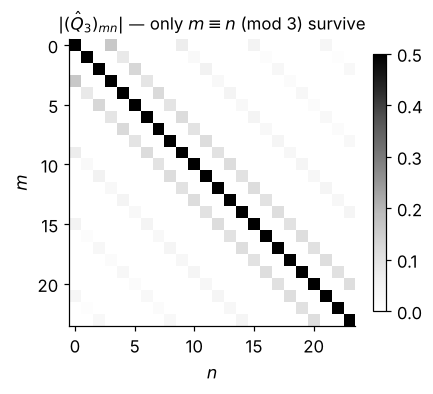

In [3]:
K = 3
Q = pr.score_operator(K, 24)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(np.abs(Q), cmap="Greys")
ax.set_xlabel("$n$"); ax.set_ylabel("$m$"); ax.set_title(r"$|(\hat Q_3)_{mn}|$ — only $m\equiv n$ (mod 3) survive")
plt.colorbar(im, ax=ax, shrink=0.8)
pl.savefig(fig, "score_operator_structure_K3", subdir="01_precession")
plt.show()

## Step 3 — the spider state for $K=3$

Diagonalise the residue-0 block (support on $|0\rangle,|3\rangle,|6\rangle,\dots$) and compare with
the other residue classes.

In [4]:
N = 3000
spider = pr.spider_state(K, N)
print(f"classical bound          P_3^c    = {pr.classical_bound(K):.4f}")
print(f"spider score (N={N})   P_3^inf  = {spider.score:.4f}")
print(f"spectral gap to 2nd eigenvalue   = {spider.gap:.4f}")
print("best residue class mod K         =", pr.best_residue(K, 600))
print("Pr[x(t_k)>0] at each of the K times:", pr.sign_probabilities(spider.psi, K).round(5))
print("first grid coefficients s_m =", spider.grid_coefficients[:8].round(4))

classical bound          P_3^c    = 0.6667
spider score (N=3000)   P_3^inf  = 0.7081
spectral gap to 2nd eigenvalue   = 0.0414
best residue class mod K         = 0


Pr[x(t_k)>0] at each of the K times: [0.7081 0.7081 0.7081]
first grid coefficients s_m = [ 0.6992 -0.5147 -0.0662  0.2572  0.0257 -0.1799 -0.0131  0.1413]


The sign pattern $(-1)^{\lceil m/2\rceil}$ of the coefficients and the value $\approx 0.708$
(at this truncation) agree with Zaw *et al.* and with the legacy figure `figures/legacy/ss_coeffs.png`.
Each of the three measurement times contributes the same probability — the state has no preferred
$t_k$, as rotation symmetry demands.

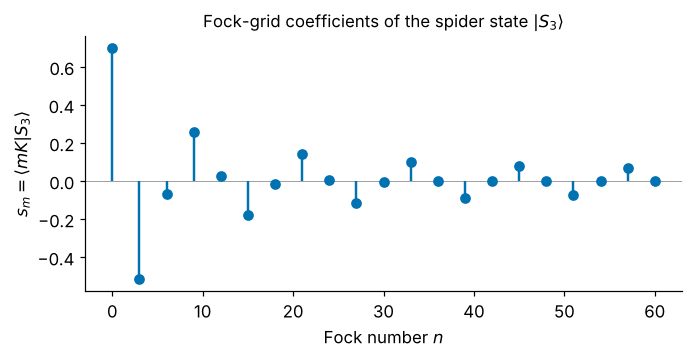

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
pl.stem_coefficients(ax, spider.grid_coefficients, K, nmax=60)
ax.set_ylabel(r"$s_{m}=\langle mK|S_3\rangle$")
ax.set_title(r"Fock-grid coefficients of the spider state $|S_3\rangle$")
pl.savefig(fig, "spider_coefficients_K3", subdir="01_precession")
plt.show()

## Step 4 — convergence with the Fock truncation, and a warning sign

The legacy plots used the *number of grid points* $n$ (Fock cutoff $= Kn$) on the $x$ axis; we do the same.
The score converges slowly, like a power law, to $\mathbf P_3^\infty\simeq 0.709$. But look at the mean
photon number: it grows like $\sqrt{n}$ and never saturates. The exact spider state has **infinite mean
energy** — any physical preparation is a truncated approximation.

fit: P_3(n) = 0.7094 - 0.040 n^(-0.50)   ->  P_3^inf = 0.7094  (classical 2/3)
mean photon number ~ 1.13 sqrt(n) + -0.08


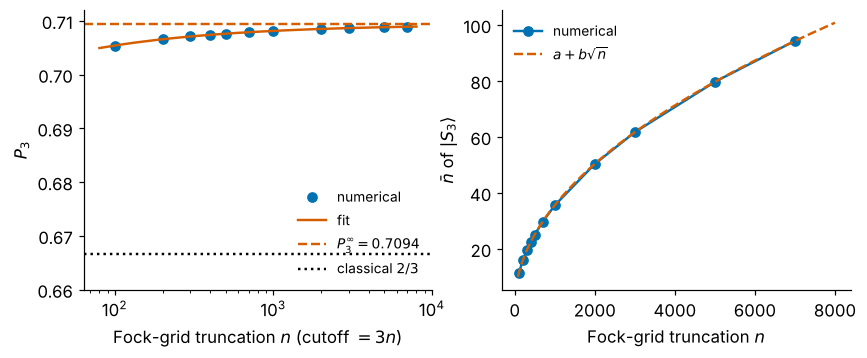

In [6]:
grid_pts = np.array([100, 200, 300, 400, 500, 700, 1000, 2000, 3000, 5000, 7000])
scan = pr.convergence_scan(K, K * grid_pts)
scores = np.array([s.score for s in scan]); nbar = np.array([s.mean_photon for s in scan])
Pinf, c, p = pr.fit_power_law_limit(grid_pts, scores)
print(f"fit: P_3(n) = {Pinf:.4f} - {c:.3f} n^(-{p:.2f})   ->  P_3^inf = {Pinf:.4f}  (classical 2/3)")
b = np.polyfit(np.sqrt(grid_pts), nbar, 1)
print(f"mean photon number ~ {b[0]:.2f} sqrt(n) + {b[1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
ax = axes[0]
ax.plot(grid_pts, scores, "o", label="numerical")
nn = np.linspace(80, 8000, 300); ax.plot(nn, Pinf - c * nn**(-p), "-", label="fit")
ax.axhline(Pinf, color="C1", ls="--", label=rf"$P_3^{{\infty}}={Pinf:.4f}$")
ax.axhline(pr.classical_bound(K), color="k", ls=":", label=r"classical $2/3$")
ax.set_xscale("log"); ax.set_xlabel("Fock-grid truncation $n$ (cutoff $=3n$)"); ax.set_ylabel("$P_3$")
ax.set_ylim(0.66, 0.712); ax.legend(loc="lower right")
ax = axes[1]
ax.plot(grid_pts, nbar, "o-", label="numerical")
ax.plot(nn, b[0]*np.sqrt(nn)+b[1], "--", color="C1", label=r"$a+b\sqrt{n}$")
ax.set_xlabel("Fock-grid truncation $n$"); ax.set_ylabel(r"$\bar n$ of $|S_3\rangle$"); ax.legend()
pl.savefig(fig, "spider_convergence_K3", subdir="01_precession")
plt.show()

The tail of the coefficients explains both facts: $|s_m|^2$ decays as a power law with an exponent between
$-1$ and $-3/2$ (the alternating large/small pattern makes a single-exponent fit crude; $\bar n\propto\sqrt n$
corresponds to $-3/2$ for the envelope). Such a tail is summable — the state is normalisable — but
$\sum_m m|s_m|^2$ is not.

|s_m| ~ m^(-0.59)   =>   |s_m|^2 ~ m^(-1.19)


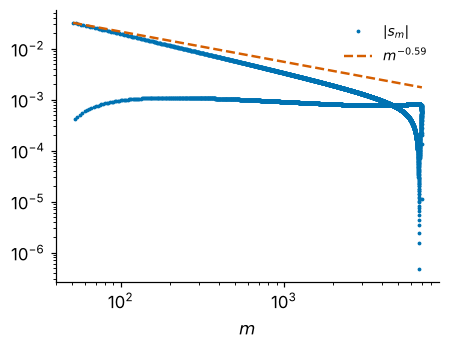

In [7]:
s = scan[-1].grid_coefficients
m = np.arange(len(s))
sel = (m > 50) & (np.abs(s) > 0)
slope = np.polyfit(np.log(m[sel]), np.log(np.abs(s[sel])), 1)[0]
print(f"|s_m| ~ m^({slope:.2f})   =>   |s_m|^2 ~ m^({2*slope:.2f})")
fig, ax = plt.subplots(figsize=(4.5, 3.2))
ax.loglog(m[sel], np.abs(s[sel]), ".", ms=3, label=r"$|s_m|$")
ax.loglog(m[sel], np.abs(s[sel][0])*(m[sel]/m[sel][0])**slope, "--", color="C1", label=rf"$m^{{{slope:.2f}}}$")
ax.set_xlabel("$m$"); ax.legend()
pl.savefig(fig, "spider_coefficient_tail_K3", subdir="01_precession")
plt.show()

## Step 5 — what does it look like? Wigner functions for $K=3$ and $K=7$

Negativity is concentrated along $K$ spokes — hence the name *spider*. (We truncate the state to
150 Fock states for the Wigner transform; this changes only the far tail.)

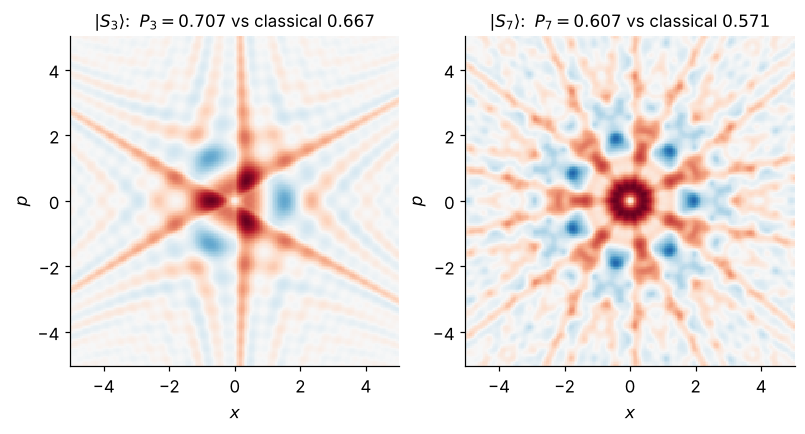

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4))
for ax, k in zip(axes, (3, 7)):
    st = pr.spider_state(k, 1200)
    xvec, W = wigner(st.psi, np.linspace(-5, 5, 201), truncate=150)
    pl.plot_wigner(ax, xvec, W, title=rf"$|S_{k}\rangle$:  $P_{k}={st.score:.3f}$ vs classical ${pr.classical_bound(k):.3f}$")
pl.savefig(fig, "spider_wigner_K3_K7", subdir="01_precession")
plt.show()

## Step 6 — summary table for several $K$

| $K$ | classical $\mathbf P_K^c$ | spider $\mathbf P_K^\infty$ (truncated) | gap to 2nd eigenvalue |
|---|---|---|---|
(filled in by the next cell)

In [9]:
rows = []
for k in (3, 5, 7, 9):
    st = pr.spider_state(k, 4000)
    rows.append((k, pr.classical_bound(k), st.score, st.gap, st.mean_photon))
    print(f"K={k}:  classical {rows[-1][1]:.4f}   spider {st.score:.4f}   gap {st.gap:.4f}   nbar(N=4000) {st.mean_photon:.1f}")
np.save("../data/spider_scores_table.npy", np.array(rows))

K=3:  classical 0.6667   spider 0.7083   gap 0.0416   nbar(N=4000) 41.1


K=5:  classical 0.6000   spider 0.6400   gap 0.0400   nbar(N=4000) 50.0
K=7:  classical 0.5714   spider 0.6080   gap 0.0366   nbar(N=4000) 57.5


K=9:  classical 0.5556   spider 0.5891   gap 0.0335   nbar(N=4000) 63.8


**Take-away for the story.** The spider state is a legitimate, normalisable, $K$-fold rotation-symmetric
state whose only defining property is *maximal* violation of the precession bound — a property that can be
certified in the lab from sign measurements alone. It has support on every $|mK\rangle$, exactly like the
logical $|+\rangle$ of an order-$K$ rotation code. Notebook 02 takes that hint seriously.